In [32]:
import os
import sys
import torch
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import catboost as cb
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader



project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.gnn.factory.model_factory import ModelFactory

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'


print("Loading dataset...")
train_data = torch.load('train_datapyg_dataset.pt', weights_only=False)
valid_data = torch.load('valid_datapyg_dataset.pt', weights_only=False)
test_data = torch.load('test_datapyg_dataset.pt', weights_only=False)
test_loader = DataLoader(test_data, batch_size=30, shuffle=False)

print(f"Train 데이터 개수: {len(train_data)}")
print(f"Valid 데이터 개수: {len(valid_data)}")
print(f"Test 데이터 개수: {len(test_data)}")


Loading dataset...
Train 데이터 개수: 6458
Valid 데이터 개수: 1387
Test 데이터 개수: 1384


In [25]:
def extract_features(data_list):
    """
    From PyG Data objects, extract features and convert to tabular format
    """
    features = []
    targets = []
    
    for data in data_list:
        # x features (node features)
        x_features = data.x.numpy().flatten()
        
        # global_x features (global features)
        global_features = data.global_x.numpy().flatten()

        combined_features = np.concatenate([x_features, global_features])
        
        features.append(combined_features)
        targets.append(data.y.item())
    
    return np.array(features), np.array(targets)


print("Preprocessing data...")
X_train, y_train = extract_features(train_data)
X_valid, y_valid = extract_features(valid_data)
X_test, y_test = extract_features(test_data)

print(f"Feature shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"Feature names: x_stats + global_features")


Preprocessing data...
Feature shape: (6458, 7401)
Target shape: (6458,)
Feature names: x_stats + global_features


In [45]:
class BaselineModels:
    def __init__(self, need_y_scaling=False):
        self.models = {}
        self.scalers = {}
        self.y_scaler = {}
        self.need_y_scaling = need_y_scaling

    def y_scaling(self, y_train, y_valid):
        if self.need_y_scaling:
            y_scaler = StandardScaler()
            y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
            y_valid_scaled = y_scaler.transform(y_valid.reshape(-1, 1))
        else:
            y_scaler = None
            y_train_scaled = y_train
            y_valid_scaled = y_valid
        return y_scaler, y_train_scaled, y_valid_scaled

    def train_linear_regression(self, X_train, y_train, X_valid, y_valid):
        """Linear Regression"""
        print("Linear Regression...")
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)
        
        y_scaler, y_train_scaled, y_valid_scaled = self.y_scaling(y_train, y_valid)

        model = LinearRegression()
        model.fit(X_train_scaled, y_train_scaled)
        
        self.models['linear_regression'] = model
        self.scalers['linear_regression'] = scaler
        self.y_scaler['linear_regression'] = y_scaler
        
        # evaluate
        y_pred = model.predict(X_valid_scaled)
        mse = mean_squared_error(y_valid_scaled, y_pred)
        mae = mean_absolute_error(y_valid_scaled, y_pred)
        r2 = r2_score(y_valid, y_pred)

        # origin scale
        y_pred_origin = y_scaler.inverse_transform(y_pred) if y_scaler else y_pred
        mse_origin = mean_squared_error(y_valid, y_pred_origin)
        mae_origin = mean_absolute_error(y_valid, y_pred_origin)
        r2_origin = r2_score(y_valid, y_pred_origin)
        
        print(f"Linear Regression (Scaled) - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        print(f"Linear Regression (Origin) - MSE: {mse_origin:.4f}, MAE: {mae_origin:.4f}, R²: {r2_origin:.4f}")
        return model, scaler, y_scaler
    
    def train_xgboost(self, X_train, y_train, X_valid, y_valid):
        """XGBoost"""
        print("XGBoost...")

        y_scaler, y_train_scaled, y_valid_scaled = self.y_scaling(y_train, y_valid)

        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train_scaled)
        
        self.models['xgboost'] = model
    
        self.y_scaler['xgboost'] = y_scaler
        
        # evaluate
        y_pred = model.predict(X_valid)
        mse = mean_squared_error(y_valid_scaled, y_pred)
        mae = mean_absolute_error(y_valid_scaled, y_pred)
        r2 = r2_score(y_valid, y_pred)

        # origin scale
        y_pred_origin = y_scaler.inverse_transform(y_pred.reshape(-1, 1)) if y_scaler else y_pred
        mse_origin = mean_squared_error(y_valid, y_pred_origin)
        mae_origin = mean_absolute_error(y_valid, y_pred_origin)
        r2_origin = r2_score(y_valid, y_pred_origin)
        
        print(f"Linear Regression (Scaled) - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        print(f"Linear Regression (Origin) - MSE: {mse_origin:.4f}, MAE: {mae_origin:.4f}, R²: {r2_origin:.4f}")
        return model, None, y_scaler

    
    def train_catboost(self, X_train, y_train, X_valid, y_valid):
        """CatBoost 모델"""
        print("CatBoost...")
        y_scaler, y_train_scaled, y_valid_scaled = self.y_scaling(y_train, y_valid)

        model = cb.CatBoostRegressor(
            iterations=100,
            depth=6,
            learning_rate=0.1,
            random_seed=42,
            verbose=False
        )
        model.fit(X_train, y_train_scaled)
        
        self.models['catboost'] = model
        self.y_scaler['catboost'] = y_scaler
        
        # evaluate
        y_pred = model.predict(X_valid)
        mse = mean_squared_error(y_valid_scaled, y_pred)
        mae = mean_absolute_error(y_valid_scaled, y_pred)
        r2 = r2_score(y_valid, y_pred)

        # origin scale
        y_pred_origin = y_scaler.inverse_transform(y_pred.reshape(-1, 1)) if y_scaler else y_pred
        mse_origin = mean_squared_error(y_valid, y_pred_origin)
        mae_origin = mean_absolute_error(y_valid, y_pred_origin)
        r2_origin = r2_score(y_valid, y_pred_origin)
        
        print(f"Linear Regression (Scaled) - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        print(f"Linear Regression (Origin) - MSE: {mse_origin:.4f}, MAE: {mae_origin:.4f}, R²: {r2_origin:.4f}")
        return model, None, y_scaler


    def evaluate_metrics(self, y_true, y_pred, prefix=''):
        # 1. MSE (Mean Squared Error)
        mse = mean_squared_error(y_true, y_pred)
        # 2. MAE (Mean Absolute Error)
        mae = mean_absolute_error(y_true, y_pred)
        # 3. RMSE (Root Mean Squared Error)
        rmse = np.sqrt(mse).item()
        # 4. R² (Coefficient of Determination)
        r2 = r2_score(y_true, y_pred)
        
        results = {
            f'{prefix}MSE': mse,
            f'{prefix}MAE': mae,
            f'{prefix}RMSE': rmse,
            f'{prefix}R²': r2,
        }
        return results
        

    def evaluate_all(self, X_test, y_test, save_path):
        import os
        os.makedirs(save_path, exist_ok=True)
        results = {}
        
        for name, model in self.models.items():
            if name == 'mlp':
                scaler = self.scalers[name]
                X_test_scaled = scaler.transform(X_test)
                X_test_tensor = torch.FloatTensor(X_test_scaled)
                
                model.eval()
                with torch.no_grad():
                    y_pred = model(X_test_tensor).numpy()
            elif name == 'linear_regression':
                scaler = self.scalers[name]
                X_test_scaled = scaler.transform(X_test)
                y_test_scaled = self.y_scaler[name].transform(y_test.reshape(-1, 1)) if self.y_scaler[name] else y_test
                y_pred = model.predict(X_test_scaled)
            else:
                y_test_scaled = self.y_scaler[name].transform(y_test.reshape(-1, 1)) if self.y_scaler[name] else y_test
                y_pred = model.predict(X_test)

            # origin scale
            y_pred_origin = self.y_scaler[name].inverse_transform(y_pred.reshape(-1, 1)) if self.y_scaler[name] else y_pred

            origin_metrics = self.evaluate_metrics(y_test, y_pred_origin, prefix='Origin_')
            scaled_metrics = self.evaluate_metrics(y_test_scaled, y_pred, prefix='Scaled_')

            all_metrics = {**origin_metrics, **scaled_metrics}
            results[name] = all_metrics

            print(f"""{name} -
            Origin_MSE: {all_metrics['Origin_MSE']:.4f}, Origin_MAE: {all_metrics['Origin_MAE']:.4f}, Origin_RMSE: {all_metrics['Origin_RMSE']:.4f}, Origin_R²: {all_metrics['Origin_R²']:.4f},
            Scaled_MSE: {all_metrics['Scaled_MSE']:.4f}, Scaled_MAE: {all_metrics['Scaled_MAE']:.4f}, Scaled_RMSE: {all_metrics['Scaled_RMSE']:.4f}, Scaled_R²: {all_metrics['Scaled_R²']:.4f}""")

            pd.DataFrame({'targets': y_test.tolist(), 'predictions': y_pred_origin.tolist()}).to_csv(os.path.join(save_path, f"scaled_{self.need_y_scaling}_{name}_predictions.csv"), index=False)

        return results


In [38]:
def best_model_predict(model, loader, device):
    model.eval()
    model.to(device)
    y_pred = []
    y_true = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data).view(-1)
            y_pred.extend(out.cpu().numpy().tolist())
            y_true.extend(data.y.cpu().numpy().reshape(-1).tolist())

    return y_pred, y_true

In [65]:
baseline_models = BaselineModels(need_y_scaling=False)
# 1. Linear Regression
baseline_models.train_linear_regression(X_train, y_train, X_valid, y_valid)

# 2. XGBoost
baseline_models.train_xgboost(X_train, y_train, X_valid, y_valid)

# 3. CatBoost
baseline_models.train_catboost(X_train, y_train, X_valid, y_valid)

print("=" * 50)
print("All models trained!")
print("=" * 50)


results = baseline_models.evaluate_all(X_test, y_test, save_path="baseline_results")


# 4. Best Model
device = 'gpu' if torch.cuda.is_available() else 'mps'
best_model = ModelFactory.create_model(
    'gcn'
)
best_model.load_state_dict(torch.load('results/best_model_gcn.pt'))
best_model_predictions, best_model_targets = best_model_predict(best_model, test_loader, device)
best_model_scores = baseline_models.evaluate_metrics(best_model_targets, best_model_predictions, 'Origin_')
best_model_results = {'best_model': best_model_scores}
best_model_results = pd.DataFrame({'best_model': best_model_scores})

all_results = pd.DataFrame(results)
all_results = pd.concat([all_results, best_model_results], axis=1).T
all_results.head()


Linear Regression...
Linear Regression (Scaled) - MSE: 1527133.5593, MAE: 882.3698, R²: 0.5969
Linear Regression (Origin) - MSE: 1527133.5593, MAE: 882.3698, R²: 0.5969
XGBoost...
Linear Regression (Scaled) - MSE: 1059948.8590, MAE: 687.2688, R²: 0.7202
Linear Regression (Origin) - MSE: 1059948.8590, MAE: 687.2688, R²: 0.7202
CatBoost...
Linear Regression (Scaled) - MSE: 1326521.0332, MAE: 765.5982, R²: 0.6498
Linear Regression (Origin) - MSE: 1326521.0332, MAE: 765.5982, R²: 0.6498
All models trained!
linear_regression -
            Origin_MSE: 1346715.0672, Origin_MAE: 824.7744, Origin_RMSE: 1160.4805, Origin_R²: 0.6500,
            Scaled_MSE: 1346715.0672, Scaled_MAE: 824.7744, Scaled_RMSE: 1160.4805, Scaled_R²: 0.6500
xgboost -
            Origin_MSE: 959912.9808, Origin_MAE: 635.1093, Origin_RMSE: 979.7515, Origin_R²: 0.7505,
            Scaled_MSE: 959912.9808, Scaled_MAE: 635.1093, Scaled_RMSE: 979.7515, Scaled_R²: 0.7505
catboost -
            Origin_MSE: 1174835.9503, Origin_

,Origin_MSE,Origin_MAE,Origin_RMSE,Origin_R²,Scaled_MSE,Scaled_MAE,Scaled_RMSE,Scaled_R²
linear_regression,1.346715e+06,824.774448,1160.480533,0.649996,1.346715e+06,824.774448,1160.480533,0.649996
xgboost,9.599130e+05,635.109283,979.751489,0.750524,9.599130e+05,635.109283,979.751489,0.750524
catboost,1.174836e+06,712.391272,1083.898496,0.694666,1.174836e+06,712.391272,1083.898496,0.694666
best_model,4.189953e+06,1553.758764,2046.937426,-0.088946,NaN,NaN,NaN,NaN


# Visualization

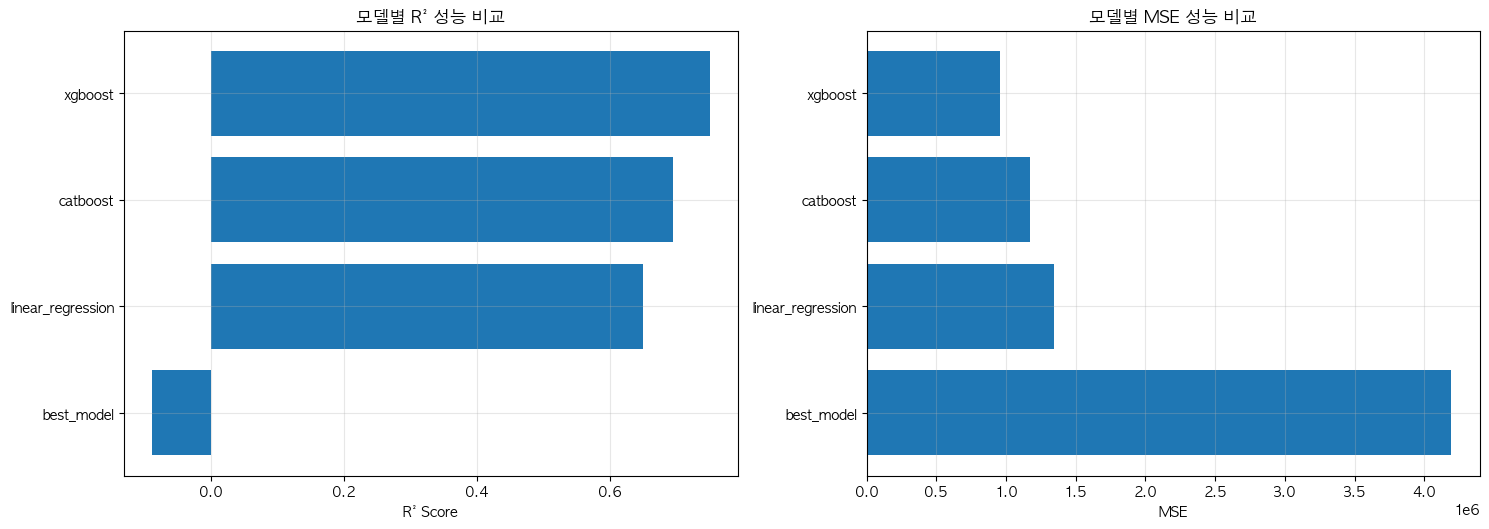

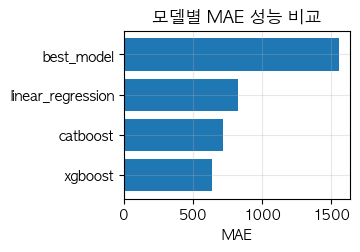

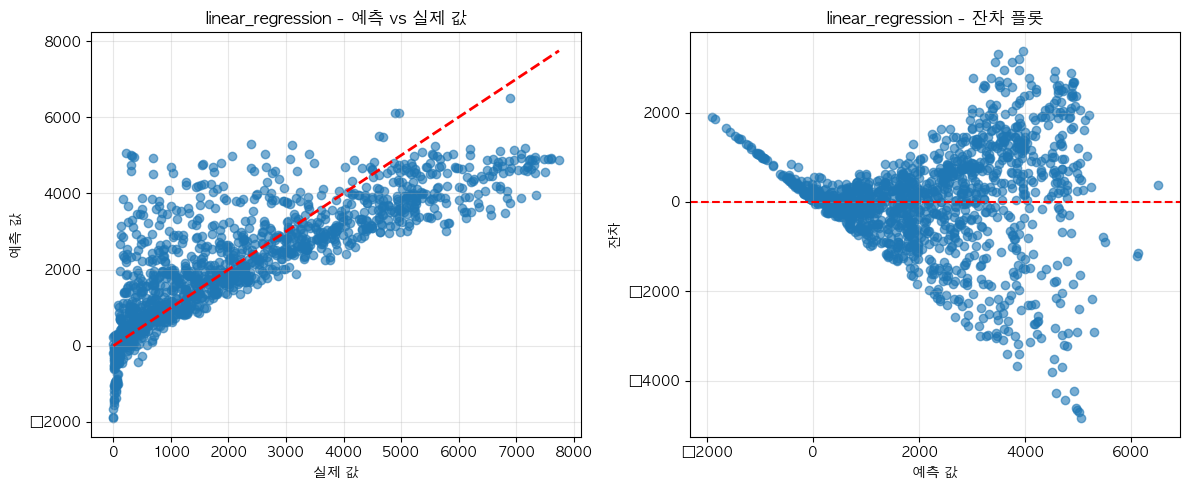

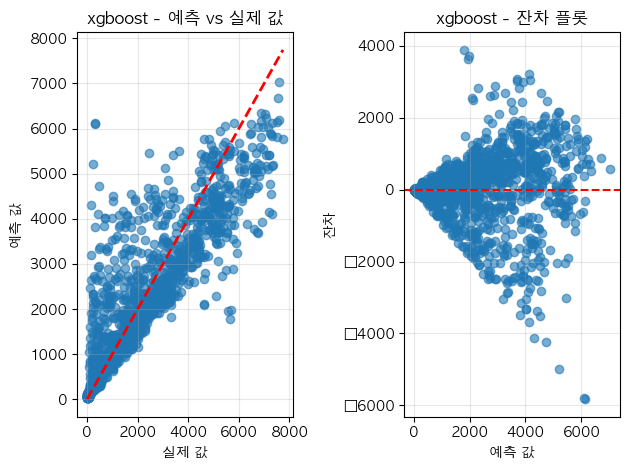

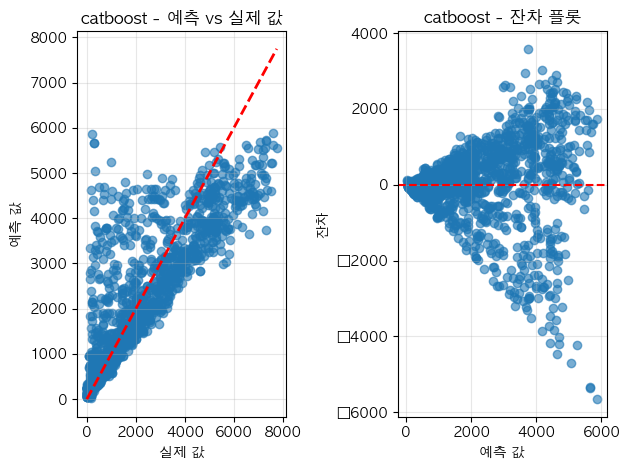

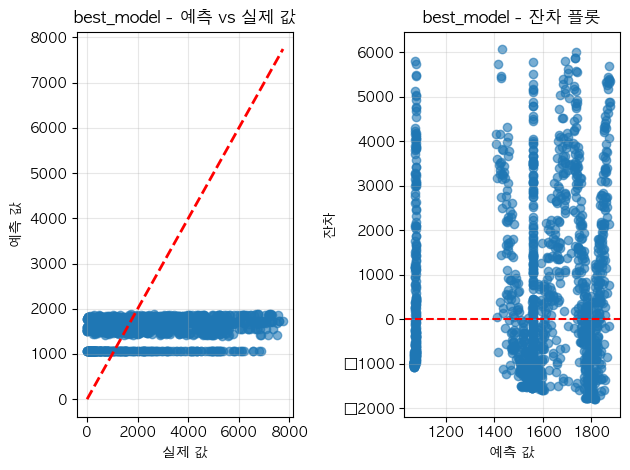

In [69]:
# 시각화 코드
# 1. 모델 성능 비교 시각화
plt.figure(figsize=(15, 10))

# R² 점수 비교
plt.subplot(2, 2, 1)
r2_scores = all_results['Origin_R²'].sort_values(ascending=True)
plt.barh(range(len(r2_scores)), r2_scores.values)
plt.yticks(range(len(r2_scores)), r2_scores.index)
plt.xlabel('R² Score')
plt.title('모델별 R² 성능 비교')
plt.grid(True, alpha=0.3)

# MSE 점수 비교
plt.subplot(2, 2, 2)
mse_scores = all_results['Origin_MSE'].sort_values(ascending=False)
plt.barh(range(len(mse_scores)), mse_scores.values)
plt.yticks(range(len(mse_scores)), mse_scores.index)
plt.xlabel('MSE')
plt.title('모델별 MSE 성능 비교')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# MAE 점수 비교
plt.subplot(2, 2, 1)
mae_scores = all_results['Origin_MAE'].sort_values(ascending=True)
plt.barh(range(len(mae_scores)), mae_scores.values)
plt.yticks(range(len(mae_scores)), mae_scores.index)
plt.xlabel('MAE')
plt.title('모델별 MAE 성능 비교')
plt.grid(True, alpha=0.3)


# 2. 예측 vs 실제 값 시각화 (최고 성능 모델)
plt.figure(figsize=(12, 5))


def predict(model_name, baseline_class, X):
    if model_name == 'linear_regression':
        scaler = baseline_class.scalers[model_name]
        X_scaled = scaler.transform(X)
    else:
        X_scaled = X_test
    model = baseline_class.models[model_name]
    y_pred = model.predict(X_scaled)

    if baseline_class.y_scaler[model_name] is not None:
        return baseline_class.y_scaler[model_name].inverse_transform(y_pred.reshape(-1, 1))
    else:
        return y_pred




model_names = ['linear_regression', 'xgboost', 'catboost', 'best_model']

for model_name in model_names:
    if model_name == 'best_model':
        y_pred = best_model_predictions
        _y_test = np.array(best_model_targets)
    else:
        y_pred = predict(model_name, baseline_models, X_test).reshape(-1)
        _y_test = np.array(y_test)
    plt.subplot(1, 2, 1)
    plt.scatter(_y_test, y_pred, alpha=0.6)
    # plt.plot([_y_test.min(), _y_test.max()], [_y_test.min(), _y_test.max()], 'r--', lw=2)
    plt.plot([_y_test.min(), _y_test.max()], [_y_test.min(), _y_test.max()], 'r--', lw=2)
    plt.xlabel('실제 값')
    plt.ylabel('예측 값')
    plt.title(f'{model_name} - 예측 vs 실제 값')
    plt.grid(True, alpha=0.3)

    # 잔차 플롯
    plt.subplot(1, 2, 2)
    residuals = _y_test - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('예측 값')
    plt.ylabel('잔차')
    plt.title(f'{model_name} - 잔차 플롯')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


